# 1. Import all packages

In [1]:
import numpy as np; from gprMax.utilities import detect_check_gpus; 
from gprMax.gprMax import api; 
import h5py; 
import matplotlib.pyplot as plt; 
import math
detect_check_gpus([0]);
import os; 
import torch
import time; 
from IPython.display import clear_output; 
os.getcwd(); 
from GPUtil import showUtilization as gpu_usage
from numba import cuda; 
import gc; 
import pycuda.driver; 
import random; 
import pandas as pd;
from scipy.signal import hilbert
from bayes_opt import BayesianOptimization; 
import plotly.graph_objects as go; 
import pickle

In [2]:
import os

os.environ["OMP_NUM_THREADS"] = "1"

In [3]:
# Function to clean GPU cache after gprMax and MCMC simulations
def free_gpu_cache():
    gc.collect()
    torch.cuda.empty_cache()
    try:
        n_devices = len(cuda.gpus)
    except Exception:
        n_devices = 0

    for dev_id in range(n_devices):
        try:
            cuda.select_device(dev_id)
            cuda.close()
            cuda.select_device(dev_id)
        except Exception:
            pass

    gpu_usage()
    gc.collect()
    torch.cuda.empty_cache()

free_gpu_cache()

| ID | GPU | MEM |
------------------
|  0 |  3% | 15% |


# 2. Load Raw experimental data

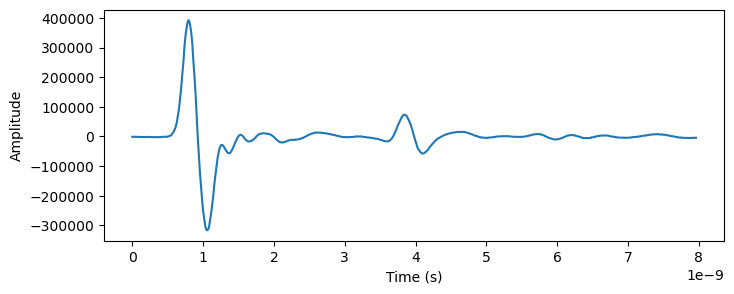

In [4]:
# Estimating perm, cond, and depth
data = pd.read_csv('ExpRawData.csv')
exp = data.iloc[1:19].mean()[2:-1];  
exp = exp - np.mean(exp)
tw=7.96e-9; 
df = 1/tw; 
fd = (exp.shape[0]-1)*df;    
dt = 1/fd; 
t = np.arange(0,tw+dt,dt);  

# Plot experimental data
plt.figure(figsize=(8, 3));
plt.plot(t,exp);
plt.xlabel('Time (s)'); 
plt.ylabel('Amplitude');

# 3. Code for FDTD simulation in gprMax

In [5]:
import os

#Simulation
tw=tw;     # Time window for FDTD simulation (time till which GPR receives signal)
pec_Y = 0.04;   # Depth of the perfect electrical conductor

def model_2L(p1, c1, p2, c2, sd2):
    sd1 = 0.15
    gpr_Y = pec_Y + sd1 + sd2
    
    # Generate unique filenames based on the Process ID
    pid = os.getpid()
    unique_input = f"Simulation_{pid}.in"
    unique_output = f"Simulation_{pid}.out"
    unique_geom = f"Sim_{pid}"

    # Write to unique input file
    with open(unique_input, "w") as f:
        f.write("#title: 15 cm soil + PEC + top layer of depth d2")
        f.write("\n#domain: 0.30 0.50 0.001")
        f.write("\n#dx_dy_dz: 0.001 0.001 0.001")  
        f.write("\n#time_window: {}".format(tw))
        f.write("\n#material: {} {} 1 0 mat1 \n#material: {} {} 1 0 mat2".format(p1, c1, p2, c2))
        f.write("\n#waveform: gaussian 1 {} my_wave".format(1.5778e9))
        f.write("\n#hertzian_dipole: z 0.12 {} 0 my_wave\n#rx: 0.18 {} 0".format(gpr_Y, gpr_Y))
        f.write("\n#box: 0 {} 0 0.3 {} 0.001 mat1".format(pec_Y, pec_Y + sd1))
        f.write("\n#box: 0 {} 0 0.3 {} 0.001 mat2".format(pec_Y+sd1, pec_Y+sd1+sd2))
        f.write("\n#box: 0 {} 0 0.30 {} 0.001 pec".format(pec_Y-0.005, pec_Y))
        # Update specific lines to use unique names if necessary, e.g. geometry view
        # It is HIGHLY recommended to remove #geometry_view for MCMC to save speed/disk
        f.close()
    
    # Run gprMax with unique input
    import subprocess
    env = os.environ.copy()
    env['CUDA_VISIBLE_DEVICES'] = ''
    subprocess.run([
        'python', '-c',
        f'from gprMax.gprMax import api; api("{unique_input}", geometry_only=False)'
    ], env=env, check=True)
    
    # Read from unique output file
    try:
        hf2 = h5py.File(unique_output, 'r', libver='latest', swmr=True)
        Ascan = hf2['rxs/rx1/Ez'][:]
        hf2.close()
    finally:
        # Cleanup: Delete the temporary files to save space
        if os.path.exists(unique_input):
            os.remove(unique_input)
        if os.path.exists(unique_output):
            os.remove(unique_output)
        # Add cleanup for .vti files if you kept geometry_view
    
    free_gpu_cache()
    # Remove clear_output() inside MCMC, it flickers badly with parallel runs
    return Ascan

In [8]:
# #Simulation
# tw=tw;     # Time window for FDTD simulation (time till which GPR receives signal)
# pec_Y = 0.04;   # Depth of the perfect electrical conductor

# def model_2L(p1, c1, p2, c2, sd2):
#     sd1=0.15;   # Depth of the soil layer
#     gpr_Y = pec_Y + sd1 + sd2;
    
#     with open("Simulation.in", "w") as f:
#         f.write("#title: 15 cm soil + PEC + top layer of depth d2")
#         f.write("\n#domain: 0.30 0.50 0.001")
#         f.write("\n#dx_dy_dz: 0.001 0.001 0.001")  
#         f.write("\n#time_window: {}".format(tw))
#         f.write("\n#material: {} {} 1 0 mat1 \n#material: {} {} 1 0 mat2".format(p1, c1, p2, c2))
#         f.write("\n#waveform: gaussian 1 {} my_wave".format(1.5778e9))
#         f.write("\n#hertzian_dipole: z 0.12 {} 0 my_wave\n#rx: 0.18 {} 0".format(gpr_Y, gpr_Y))
#         f.write("\n#box: 0 {} 0 0.3 {} 0.001 mat1".format(pec_Y, pec_Y + sd1))
#         f.write("\n#box: 0 {} 0 0.3 {} 0.001 mat2".format(pec_Y+sd1, pec_Y+sd1+sd2))
#         f.write("\n#box: 0 {} 0 0.30 {} 0.001 pec".format(pec_Y-0.005, pec_Y))
#         f.write("\n#geometry_view: 0 0 0  0.30 0.50 0.001  0.001 0.001 0.001 Sim n\n")
#         f.close()
    
#     # Run gprMax in subprocess with CUDA disabled (avoids sm_120 compilation error)
#     import subprocess
#     env = os.environ.copy()
#     env['CUDA_VISIBLE_DEVICES'] = ''  # Hide all CUDA devices
#     subprocess.run([
#         'python', '-c',
#         'from gprMax.gprMax import api; api("Simulation.in", geometry_only=False)'
#     ], env=env, check=True)
    
#     hf2 = h5py.File("Simulation.out",'r', libver='latest', swmr=True)
#     Ascan = hf2['rxs/rx1/Ez'][:];  
#     hf2.close();    
#     free_gpu_cache();    
#     clear_output();    
#     print('Parameters:', p1, c1, p2, c2, sd2)
#     return Ascan


## Running an example simulation
sim = model_2L(p1=14, c1=0, p2=3, c2=0, sd2=0.05)

| ID | GPU | MEM |
------------------
|  0 |  1% | 15% |


# 4. Making experimental and numerical signal the same size

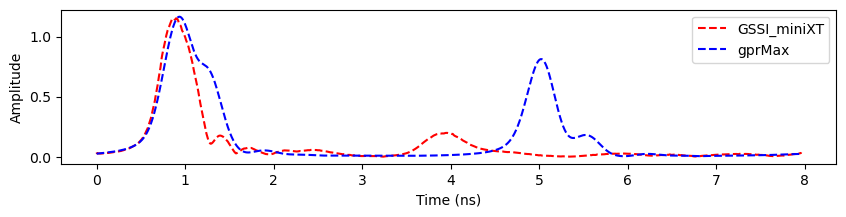

In [9]:
# Changing shape of the experimental signal
original_vector = -exp
new_size = sim.shape[0]  # Specify the desired new size
original_indices = np.arange(original_vector.size) # Create an array of indices for the original vector
new_indices = np.linspace(0, original_indices.max(), new_size) # Create an array of indices for the new vector
E_new = np.interp(new_indices, original_indices, original_vector) # Perform linear interpolation

E_new_normalized = E_new/(np.max(abs(E_new)));          # Normalize the experimental signals   
sim_normalized = sim/(np.max(abs(sim)))                 # Normalize the simulational signals   

E_new_normalized = np.abs(hilbert(E_new_normalized));   # Hilbert transform of experimental signal
sim_normalized = np.abs(hilbert(sim_normalized))        # Hilbert transform of simulational signal


# Plot comparison of experimental and numerical signal with RANDOM incorrect parameter values
df = 1/tw; 
fd = (E_new_normalized.shape[0]-1)*df;    
dt = 1/fd;  
t = np.arange(0,tw+dt,dt);  
t = t*1e9; 

plt.figure(figsize=(10, 2))
plt.plot(t,E_new_normalized,color='red',label='GSSI_miniXT', linestyle='--'); 
plt.plot(t,sim_normalized,color='blue',label='gprMax', linestyle='--'); 
plt.xlabel('Time (ns)'); 
plt.ylabel('Amplitude'); 
plt.legend(); 
plt.show();


# 5. Bayesian Optimization

In [8]:
from bayes_opt import BayesianOptimization

#-- Error Function:
def mae_func(p1, c1, p2, c2, sd2):
    vector1 = E_new_normalized;    
    vector2 = model_2L(p1, c1, p2, c2, sd2)
    vector2 = np.abs(hilbert(vector2/(np.max(abs(vector2)))))
    rel_error = -100*np.sqrt(np.sum((vector1 - vector2)**2))/(np.sqrt(np.sum(vector1**2))) # Relative error (objective function)
    return rel_error

#-- Setting upper and lower bounds of each parameter:
bounds = {'p1':(1,23), 
          'c1':(0,0.15), 
          'p2':(1,15), 
          'c2':(0,0.03), 
          'sd2':(0.02,0.2)};     

#-- Initializing Bayesian Optimization:
optimizer = BayesianOptimization(f=mae_func, 
                                 pbounds=bounds, 
                                 random_state=42)

#-- Running Bayesian Optimization with initial points and iterations:
# optimizer.maximize(init_points=550, n_iter=200)
optimizer.maximize(init_points=100, n_iter=20)

#-- Printing completion message and the best parameters found:
print("Optimization completed successfully.");
print(optimizer.max)

Parameters: 6.634575943455465 0.15 1.0 0.03 0.2
| 120       | -29.57526 | 6.6345759 | 0.15      | 1.0       | 0.03      | 0.2       |
Optimization completed successfully.
{'target': np.float64(-21.373315650069873), 'params': {'p1': np.float64(1.1382065056631014), 'c1': np.float64(0.15), 'p2': np.float64(2.9736354179592643), 'c2': np.float64(0.03), 'sd2': np.float64(0.2)}}


# 6. Bayesian Inference using MCMC

In [ ]:
from multiprocessing.pool import Pool

import emcee

t_total=[]; 
t0 = time.time()


# Setting bounds for parameter space
bounds = {'p1': (1,23), 'c1': (0,0.1), 'p2': (1,9), 'c2': (0,0.1),  'sd2': (0.02, 0.18)}


# Likelihood function
def mae_func(p1, c1, p2, c2, sd2):
    vector1 = E_new_normalized                  # Experimental signal (normalized amplitude envelope)
    vector2 = model_2L(p1, c1, p2, c2, sd2)     # Run gprMax Simulation
    vector2 = vector2/(np.max(abs(vector2)))    # Normalizing simulation signal
    vector2 = np.abs(hilbert(vector2))          # Simulation signal (normalized amplitude envelope)
    
    error = vector1-vector2     # compute error
    sigma = np.std(error)       # compute the standard deviation of the residual
    result = np.sum(0.5*(error/sigma)**2 + np.log(np.sqrt(2*3.1416)*sigma)) #calculate the log likelihood
    
    return -result # We want to maximize the negative log likelihood



# Define the log-posterior distribution function
def log_posterior(params):
    p1, c1, p2, c2, sd2 = params
    
    # Check if parameters are within bounds
    if (p1 < 1 or p1 > 23 or c1 < 0 or c1 > 0.1 or p2 < 1 or p2 > 9 or c2 < 0 or c2 > 0.1 or sd2 <0.02 or sd2 > 0.18):
        return -np.inf # Return -inf if the parameters are outside the bounds
    else:
        # Evaluate the log-posterior distribution as the negative of the objective function
        log_likelihood = mae_func(p1, c1, p2, c2, sd2)
        return log_likelihood       # No prior added as unifrom prior is assumed
    

# Set the number of walkers and the number of steps for the MCMC sampler
nwalkers = 20
# nsteps = 160
nsteps = 1


# Set the initial positions of the walkers by sampling from the prior distribution
p0 = np.random.uniform(low =[bounds['p1'][0], bounds['c1'][0], bounds['p2'][0], bounds['c2'][0], bounds['sd2'][0]], 
                       high=[bounds['p1'][1], bounds['c1'][1], bounds['p2'][1], bounds['c2'][1], bounds['sd2'][1]], 
                       size=(nwalkers, 5))


with Pool() as pool:
    # Initialize the MCMC sampler, Run the sampler and get the posterior samples
    sampler = emcee.EnsembleSampler(nwalkers, 5, log_posterior, pool=pool) # Initialize the MCMC sampler
    pos, prob, state = sampler.run_mcmc(p0, nsteps, progress=True)             # Run the MCMC sampler
    samples = sampler.flatchain                                 # Get the posterior samples


    # Calculate the end time and print the time needed to complete
    t1 = time.time(); 
    t_total.append(t1 - t0); 
    print('Time (hrs)=', np.array(t_total)/3600)

In [1]:
from multiprocessing import cpu_count

ncpu = cpu_count()
print("{0} CPUs".format(ncpu))

16 CPUs


## 6a. Plot the posterior distributions of the parameters


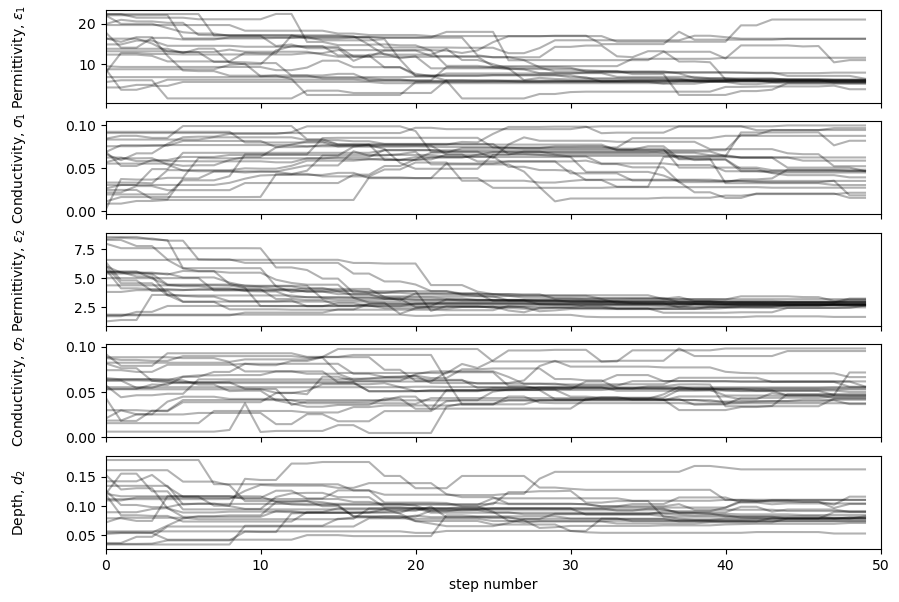

In [41]:
ndim = 5

fig, axes = plt.subplots(5, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels=[r"Permittivity, $\varepsilon_1$", r"Conductivity, $σ_1$", r"Permittivity, $\varepsilon_2$", r"Conductivity, $σ_2$", r"Depth, $d_2$"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [42]:
tau = sampler.get_autocorr_time()
print(tau)

AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 1;
tau: [5.54521036 4.78122302 5.89715402 4.97268711 5.06586868]

In [ ]:
flat_chain = sampler.get_chain(flat=True) # Get the flat chain with shape (nwalkers * nsteps, ndim)

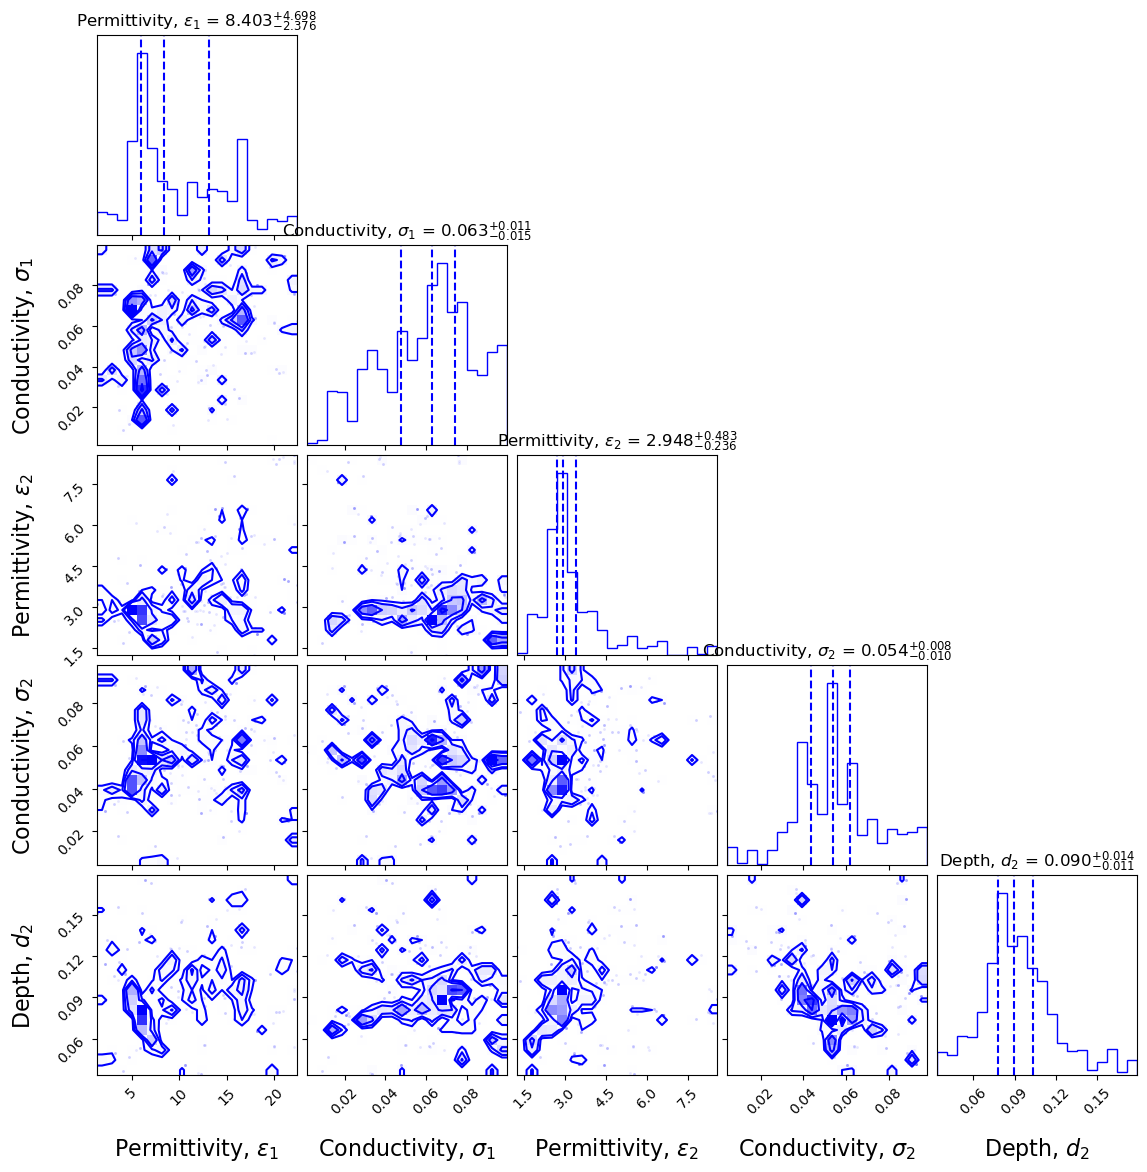

In [ ]:
import corner
label_props = {'fontsize': 16}

fig = corner.corner(flat_chain, 
                    quantiles=[.30, .50, .70], 
                    labels=[r"Permittivity, $\varepsilon_1$", r"Conductivity, $σ_1$", r"Permittivity, $\varepsilon_2$", r"Conductivity, $σ_2$", r"Depth, $d_2$"], 
                    color='b', show_titles=True, title_fmt='.3f', label_kwargs=label_props)

# 7. Compare experimental and numerical signal with predicted parameters

Parameters: 4.1 0.03 3.47 0.014 0.109


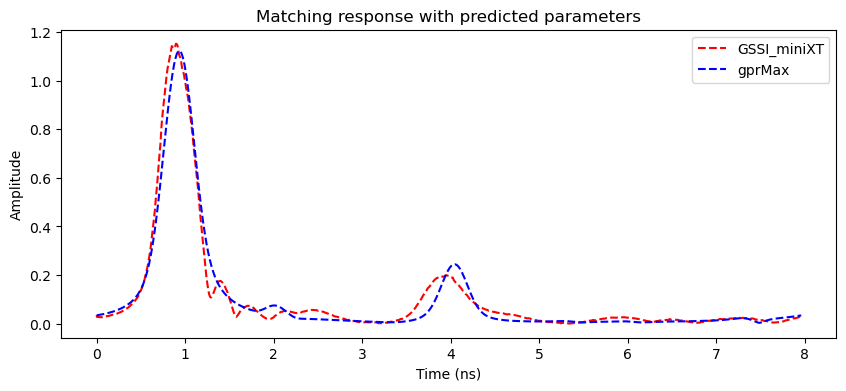

np.float64(16.405640683558065)

In [12]:
# Run simulation with predicted parameter values
sim = model_2L(p1=4.1, c1=.03, p2=3.47, c2=.014, sd2= 0.109)

# Changing shape of the experimental signal
original_vector = -exp
new_size = sim.shape[0]  # Specify the desired new size
original_indices = np.arange(original_vector.size) # Create an array of indices for the original vector
new_indices = np.linspace(0, original_indices.max(), new_size) # Create an array of indices for the new vector
E_new = np.interp(new_indices, original_indices, original_vector) # Perform linear interpolation

E_new_normalized = E_new/(np.max(abs(E_new)));          # Normalize the experimental signals   
sim_normalized = sim/(np.max(abs(sim)))                 # Normalize the simulational signals   

E_new_normalized = np.abs(hilbert(E_new_normalized));   # Hilbert transform of experimental signal
sim_normalized = np.abs(hilbert(sim_normalized))        # Hilbert transform of simulational signal


# Plot the two results
df = 1/tw; 
fd = (E_new_normalized.shape[0]-1)*df;    
dt = 1/fd;  
t = np.arange(0,tw+dt,dt);  
t = t*1e9; 

plt.figure(figsize=(10, 4))
plt.plot(t,E_new_normalized,color='red',label='GSSI_miniXT', linestyle='--'); 
plt.plot(t,sim_normalized,color='blue',label='gprMax', linestyle='--'); 
plt.xlabel('Time (ns)'); 
plt.ylabel('Amplitude'); 
plt.title('Matching response with predicted parameters')
plt.legend(); 
plt.show();

100*np.sqrt(np.sum((E_new_normalized - sim_normalized)**2))/(np.sqrt(np.sum(E_new_normalized**2)))
